In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [2]:
X, y = make_blobs()

In [3]:
k=5
kmeans = KMeans(n_clusters=k, random_state=42) 
y_pred = kmeans.fit_predict(X)

In [4]:
y_pred

array([2, 1, 3, 0, 4, 2, 2, 1, 2, 0, 3, 2, 1, 0, 3, 4, 2, 0, 3, 2, 1, 2,
       1, 2, 2, 4, 2, 2, 3, 3, 2, 4, 1, 0, 4, 1, 4, 0, 3, 2, 3, 3, 1, 4,
       4, 2, 4, 4, 2, 2, 2, 1, 1, 3, 1, 2, 2, 3, 3, 2, 0, 1, 3, 3, 1, 2,
       0, 2, 2, 1, 1, 1, 3, 2, 1, 1, 2, 2, 2, 2, 3, 2, 1, 1, 4, 2, 1, 1,
       0, 2, 3, 1, 3, 3, 3, 0, 2, 3, 3, 0], dtype=int32)

In [5]:
y_pred is kmeans.labels_

True

In [6]:
kmeans.cluster_centers_

array([[-7.74188014e+00, -3.75674825e+00],
       [ 5.72209186e-03,  9.14612400e+00],
       [ 4.41738373e+00, -3.12491181e+00],
       [-8.34949609e+00, -5.25301097e+00],
       [-1.54030318e+00,  7.55488703e+00]])

In [7]:
import numpy as np

In [8]:
X_new = np.array([[0,2],[3,2],[-3,3],[-3,2.5]])

In [9]:
kmeans.predict(X_new)

array([4, 2, 4, 4], dtype=int32)

In [10]:
kmeans.transform(X_new).round(2)

array([[ 9.65,  7.15,  6.77, 11.06,  5.76],
       [12.19,  7.75,  5.32, 13.47,  7.17],
       [ 8.25,  6.84,  9.62,  9.84,  4.78],
       [ 7.85,  7.29,  9.31,  9.42,  5.26]])

In [11]:
good_init = np.array([[-3,3], [-3,2], [-3,1], [-1,2], [0,2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
kmeans.fit(X)

,n_clusters,5
,init,"array([[-3, ... [ 0, 2]])"
,n_init,1
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [12]:
kmeans.inertia_

149.1577077260506

In [13]:
kmeans.score(X)

-149.1577077260506

In [14]:
from sklearn.cluster import MiniBatchKMeans

In [15]:
minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42) 
minibatch_kmeans.fit(X)

,n_clusters,5
,init,'k-means++'
,max_iter,100
,batch_size,1024
,verbose,0
,compute_labels,True
,random_state,42
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,'auto'


In [16]:
import matplotlib.pyplot as plt

In [17]:
from sklearn.metrics import silhouette_score

In [18]:
silhouette_score(X, kmeans.labels_)

0.6855076361560518

In [19]:
import PIL
filepath = 'ladybug.png'

In [20]:
image = np.asarray(PIL.Image.open(filepath))

In [21]:
image.shape

(189, 280, 4)

In [22]:
X = image.reshape(-1,3)

In [23]:
X

array([[255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       ...,
       [255, 140, 168],
       [130, 255, 130],
       [154, 127, 255]], shape=(70560, 3), dtype=uint8)

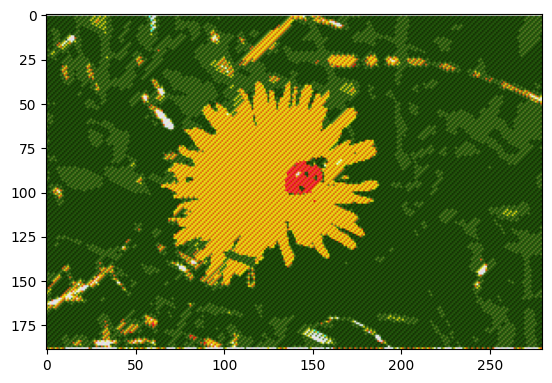

In [24]:
kmeans = KMeans(n_clusters=8, random_state=42).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)
plt.imshow(segmented_img.astype('uint8'))

In [25]:
from sklearn.datasets import load_digits

In [26]:
X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_digits[:n_labeled])

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [29]:
log_reg.score(X_test, y_test)

0.7581863979848866

In [30]:
k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0) 
X_representative_digits = X_train[representative_digit_idx]

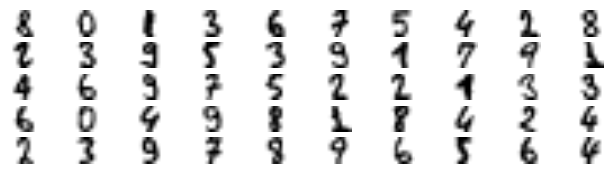

In [31]:
# extra code – this cell generates and saves Figure 9–13

plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

plt.show()

In [32]:
y_representative_digits = np.array([8,0,1,3,6,7,5,4,2,8,2,3,9,5,3,9,1,7,9,2,4,6,9,7,5,2,2,4,3,3,6,0,4,9,8,2,8,4,2,4,2,3,9,7,8,9,6,5,6,4])

In [33]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test,y_test)

0.8161209068010076

In [34]:
y_train_propogated = np.empty(len(X_train), dtype=np.int64) 
for i in range(k):
    y_train_propogated[kmeans.labels_ == i] = y_representative_digits[i]

In [35]:
kmeans.labels_

array([31,  2, 38, ...,  7,  7,  5], shape=(1400,), dtype=int32)

In [36]:
y_train_propogated

array([0, 1, 2, ..., 4, 4, 7], shape=(1400,))

In [37]:
log_reg = LogisticRegression(max_iter=10_000) 
log_reg.fit(X_train, y_train_propogated) 
log_reg.score(X_test, y_test)

0.836272040302267

In [38]:
percentile_closest = 99

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k): 
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propogated = (X_cluster_dist != -1)
X_train_partially_propogated = X_train[partially_propogated]
y_train_partially_propogated = y_train[partially_propogated]

In [39]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_partially_propogated, y_train_partially_propogated) 
log_reg.score(X_test, y_test)

0.9118387909319899

In [40]:
(y_train_partially_propogated == y_train[partially_propogated]).mean()

np.float64(1.0)

In [41]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [42]:
X, y = make_moons(n_samples=1_000, noise=0.05) 
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

,eps,0.05
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [43]:
dbscan.labels_

array([ 0,  0,  0,  1,  2,  3,  2,  3,  0,  3,  1,  5,  0,  0,  0,  3,  0,
        3,  0,  1,  1,  3,  4,  1,  4,  1,  4,  1,  4,  0,  0,  2,  3,  5,
        3,  2,  2,  5,  0,  3,  3,  0, -1,  0, -1,  0,  1,  4,  1,  4,  3,
        0,  0,  0,  3,  3,  4,  1,  1,  1,  5,  4,  0,  1,  3,  4,  2,  0,
        3,  0,  1,  1,  0,  1,  0,  0,  0,  3,  0,  0,  3,  0,  1,  5,  3,
        0,  2,  1,  4,  0,  2,  2,  0,  6,  1,  0,  0,  4,  3,  0,  3,  4,
        3,  4,  2,  1,  3,  3,  3,  4,  3,  0,  4,  0,  4,  3,  0,  2,  1,
        2,  3,  7,  3,  4,  4,  3,  0,  2,  0,  3,  2,  1,  4,  3,  0,  2,
        1,  1,  6,  3,  0,  7,  2,  0,  0, -1,  3, -1,  0,  0, -1,  4, -1,
        1,  4,  1,  0,  2,  1,  1,  3, -1,  3,  3,  3,  4,  3,  4,  1,  0,
        3,  1,  3,  0,  0,  4,  3,  1,  5,  0,  2,  2,  3,  3,  1,  0,  4,
        2,  2, -1,  0,  3,  5, -1,  1,  1,  3,  1,  4,  3,  4,  0,  6,  8,
        1, -1,  3,  0,  3,  0,  1,  1,  1,  0,  0,  0,  1,  0,  3,  3,  3,
        4, -1,  4,  0,  3

In [44]:
dbscan.core_sample_indices_

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  13,  14,
        15,  16,  17,  18,  19,  20,  21,  22,  24,  25,  26,  29,  30,
        31,  32,  33,  36,  37,  38,  39,  40,  41,  43,  45,  47,  48,
        49,  50,  51,  52,  53,  55,  56,  57,  58,  59,  60,  61,  62,
        63,  64,  65,  66,  67,  68,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  88,  89,  90,
        91,  92,  93,  94,  96,  98,  99, 100, 103, 104, 105, 106, 107,
       108, 109, 110, 111, 112, 118, 119, 120, 121, 123, 124, 125, 127,
       128, 129, 131, 132, 133, 134, 135, 136, 137, 138, 140, 141, 142,
       143, 144, 146, 148, 149, 151, 153, 154, 155, 156, 157, 158, 159,
       160, 162, 163, 164, 165, 167, 169, 170, 171, 172, 173, 174, 175,
       176, 177, 178, 179, 180, 181, 183, 184, 185, 186, 187, 188, 190,
       194, 196, 199, 200, 202, 204, 206, 207, 208, 209, 210, 212, 213,
       214, 215, 217, 218, 219, 220, 221, 223, 224, 226, 227, 22

In [45]:
dbscan.components_

array([[ 0.45184615,  0.96239074],
       [ 0.51557915,  0.86533126],
       [-0.37198164,  0.85990338],
       ...,
       [-0.6074066 ,  0.83725854],
       [ 0.22273353, -0.13209553],
       [-0.87192385,  0.52949559]], shape=(794, 2))

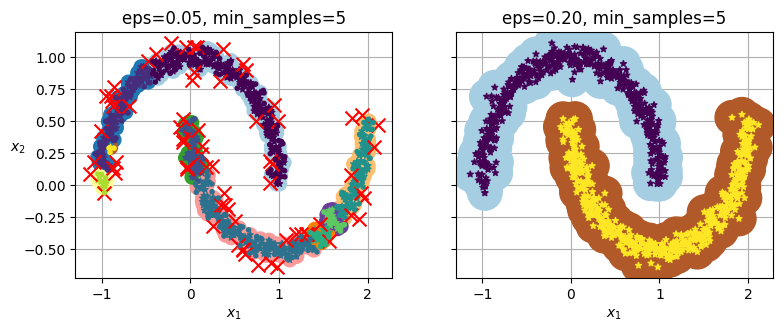

In [46]:
# extra code – this cell generates and saves Figure 9–14

def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]
    
    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

plt.show()

In [47]:
dbscan = dbscan2

In [48]:
from sklearn.neighbors import KNeighborsClassifier

In [49]:
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

,n_neighbors,50
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [50]:
X_new = np.array([[-0.5,0],[0,0.5],[1,-0.1],[2,1]])

In [51]:
knn.predict(X_new)

array([0, 1, 0, 1])

In [52]:
knn.predict_proba(X_new)

array([[0.78, 0.22],
       [0.  , 1.  ],
       [0.82, 0.18],
       [0.  , 1.  ]])

In [53]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)

In [54]:
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]

In [55]:
y_pred[y_dist > 0.2] = -1

In [56]:
y_pred.ravel()

array([-1,  1,  0, -1])

In [57]:
from sklearn.mixture import GaussianMixture

In [58]:
gm = GaussianMixture(n_components=3, n_init=10)
gm.fit(X)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,10
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


In [59]:
gm.weights_

array([0.19853351, 0.59530495, 0.20616153])

In [60]:
gm.means_

array([[-0.75856322,  0.55153912],
       [ 0.49009731,  0.26294731],
       [ 1.73900972, -0.06804126]])

In [61]:
gm.covariances_

array([[[ 0.04845364,  0.05779453],
        [ 0.05779453,  0.08732244]],

       [[ 0.17347862, -0.10189892],
        [-0.10189892,  0.29192361]],

       [[ 0.05561909,  0.06250431],
        [ 0.06250431,  0.08929373]]])

In [62]:
gm.converged_

True

In [63]:
gm.n_iter_

18

In [64]:
gm.predict(X)

array([1, 1, 0, 0, 1, 2, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       2, 0, 2, 0, 2, 0, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       2, 1, 0, 2, 0, 2, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 2, 2, 1, 0, 1, 2,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 0,
       2, 1, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 2, 2, 2, 1, 0, 1, 1, 1, 2,
       1, 1, 2, 1, 2, 1, 1, 1, 0, 1, 1, 0, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0,
       2, 1, 0, 1, 0, 0, 2, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 2, 1, 0,
       2, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 0, 1, 1, 0, 1, 1, 1, 2,
       1, 0, 2, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 2, 1, 1, 2, 0, 0, 0, 1, 0,
       2, 2, 2, 1, 2, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 2, 1, 2, 1, 2, 1, 1, 0, 2, 1, 1, 2, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 2, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 2, 0, 1, 0, 1, 1,
       1, 2, 0, 0, 1, 1, 1, 0, 1, 1, 1, 2, 1, 1, 0, 1, 2, 2, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [65]:
gm.predict_proba(X).round(3)

array([[0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.688, 0.312, 0.   ],
       ...,
       [0.977, 0.023, 0.   ],
       [0.   , 1.   , 0.   ],
       [0.998, 0.002, 0.   ]], shape=(1000, 3))

In [66]:
X_new, y_new = gm.sample(6)

In [67]:
X_new

array([[-0.69812659,  0.82352223],
       [ 0.63991322,  0.78874732],
       [ 0.69659233,  0.40134068],
       [ 1.21237652,  0.16310162],
       [ 0.82906411, -0.48711149],
       [ 1.87359993, -0.0342535 ]])

In [68]:
y_new

array([0, 1, 1, 1, 1, 2])

In [69]:
gm.score_samples(X).round(2)

array([-1.74, -1.57, -1.75, -0.74, -1.55, -1.02, -1.48, -1.66, -1.59,
       -1.8 , -0.44, -0.84, -1.4 , -1.67, -1.66, -1.7 , -1.69, -1.26,
       -1.59, -0.69, -0.11, -1.51, -1.75, -1.56, -0.58, -0.18, -0.07,
       -1.51, -1.92, -1.54, -1.7 , -1.4 , -1.92, -1.12, -2.17, -1.7 ,
       -1.39, -0.64, -1.44, -2.04, -1.64, -1.54, -2.02, -1.52, -4.62,
       -1.64, -1.1 , -1.13, -0.51, -0.94, -1.85, -1.5 , -1.6 , -1.44,
       -1.56, -1.78, -0.33, -0.37, -0.16, -0.13, -0.48, -0.11, -1.52,
       -0.87, -1.63, -0.61, -1.66, -1.92, -1.86, -1.8 , -0.95, -0.24,
       -1.45, -0.81, -1.6 , -1.65, -1.91, -1.9 , -1.47, -2.24, -1.9 ,
       -1.42, -0.16, -0.51, -1.82, -1.51, -1.44, -1.01, -2.28, -1.59,
       -1.59, -1.42, -1.53, -0.33, -0.48, -1.78, -1.47, -1.5 , -2.1 ,
       -1.7 , -2.2 , -0.04, -1.31, -0.04, -1.7 , -0.49, -1.59, -1.68,
       -1.43, -1.75, -1.86, -1.52, -1.11, -1.78, -2.99, -1.39, -1.49,
       -1.81, -0.14, -1.35, -2.02, -1.57, -0.99, -0.75, -0.83, -1.72,
       -1.41, -1.45,

In [70]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 2)
anomalies = X[densities < density_threshold]

In [71]:
gm.bic(X)

np.float64(2844.126357235987)

In [72]:
gm.aic(X)

np.float64(2760.6945174932907)

In [73]:
from sklearn.mixture import BayesianGaussianMixture

In [74]:
bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)

In [75]:
bgm.fit(X)

C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


,n_components,10
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,10
,init_params,'kmeans'
,weight_concentration_prior_type,'dirichlet_process'
,weight_concentration_prior,None
,mean_precision_prior,None
,mean_prior,None


In [76]:
bgm.weights_.round(2)

array([0.12, 0.17, 0.16, 0.12, 0.14, 0.08, 0.1 , 0.12, 0.  , 0.  ])

In [77]:
from sklearn.datasets import fetch_olivetti_faces

In [78]:
faces = fetch_olivetti_faces()
X, y = faces.data, faces.target

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.15, stratify=y)

In [81]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=42, test_size=0.176, stratify=y_train)

In [82]:
len(X_train) / len(X)

0.7

In [83]:
from sklearn.decomposition import PCA
pca = PCA(0.99)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.fit_transform(X_test)
X_val_pca = pca.fit_transform(X_val)

In [84]:
# Calculate silhouette scores for up to 10 clusters
n_clusters = np.arange(5, 200, 5)
k_ranges = []
for i in n_clusters:
    print(f"k={i}")
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    kmeans.fit(X_train_pca)
    k_ranges.append(kmeans)

k=5
k=10
k=15
k=20
k=25
k=30
k=35
k=40
k=45
k=50
k=55
k=60
k=65
k=70
k=75
k=80
k=85
k=90
k=95
k=100
k=105
k=110
k=115
k=120
k=125
k=130
k=135
k=140
k=145
k=150
k=155
k=160
k=165
k=170
k=175
k=180
k=185
k=190
k=195


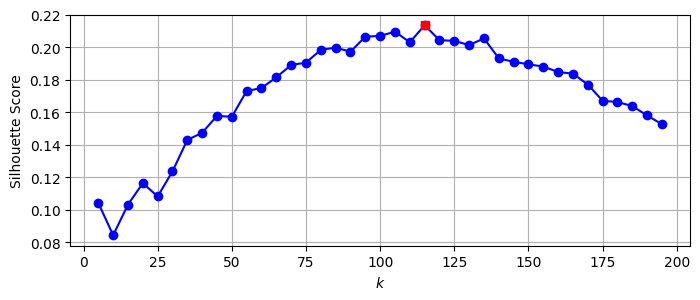

In [85]:
# Graph Silhouette Scores
silhouette_scores = [silhouette_score(X_train_pca, model.labels_) for model in k_ranges]
best_index = np.argmax(silhouette_scores)
best_k = n_clusters[best_index]
best_score = silhouette_scores[best_index]

plt.figure(figsize=(8,3)) 
plt.plot(n_clusters, silhouette_scores, 'bo-')
plt.plot(best_k, best_score, 'rs')
plt.xlabel("$k$")
plt.ylabel("Silhouette Score")
plt.grid() 
plt.show()

In [86]:
print(best_k)

115


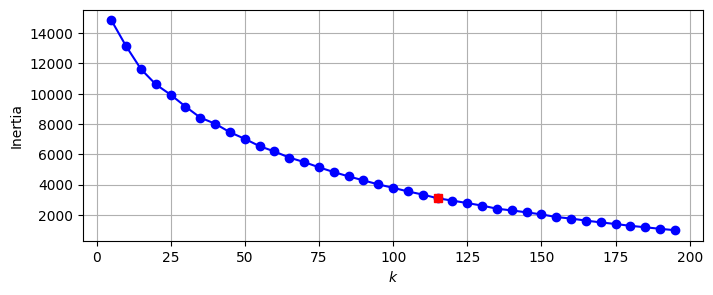

In [87]:
inertias = [model.inertia_ for model in k_ranges]
lowest_inertia = inertias[best_index]

plt.figure(figsize=(8,3))
plt.plot(n_clusters, inertias, 'bo-')
plt.plot(best_k, lowest_inertia, 'rs')
plt.xlabel("$k$") 
plt.ylabel('Inertia')
plt.grid() 
plt.show()

In [88]:
best_model = k_ranges[best_index]

Cluster 0


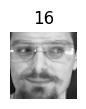

Cluster 1


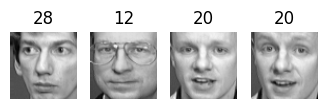

Cluster 2


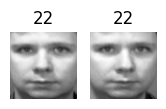

Cluster 3


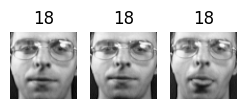

Cluster 4


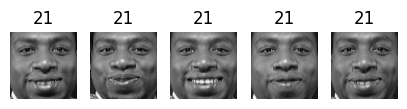

Cluster 5


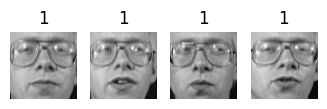

Cluster 6


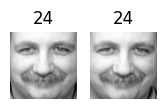

Cluster 7


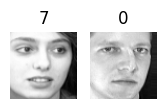

Cluster 8


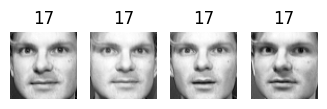

Cluster 9


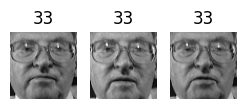

Cluster 10


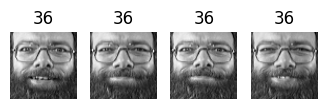

Cluster 11


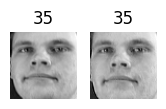

Cluster 12


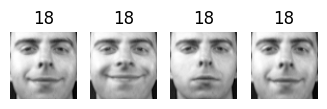

Cluster 13


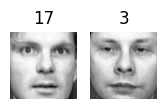

Cluster 14


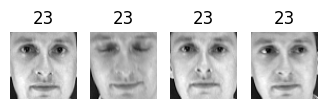

Cluster 15


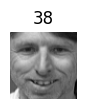

Cluster 16


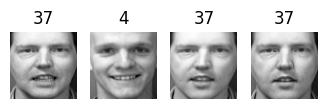

Cluster 17


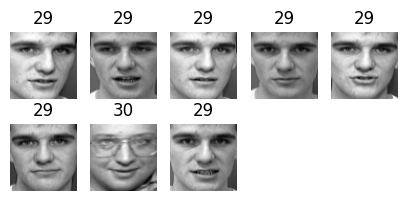

Cluster 18


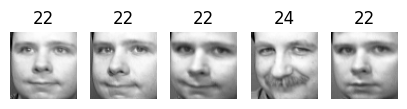

Cluster 19


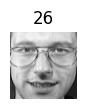

Cluster 20


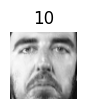

Cluster 21


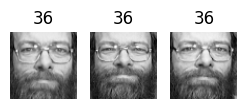

Cluster 22


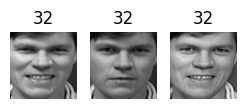

Cluster 23


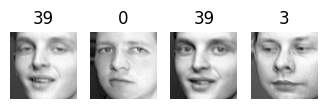

Cluster 24


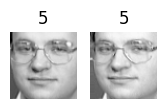

Cluster 25


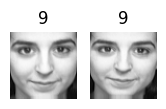

Cluster 26


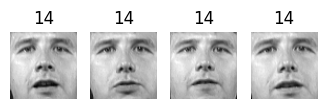

Cluster 27


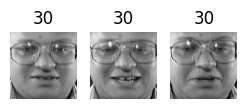

Cluster 28


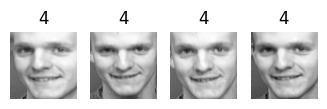

Cluster 29


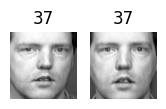

Cluster 30


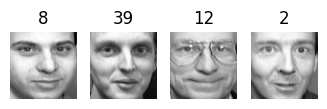

Cluster 31


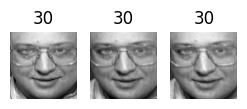

Cluster 32


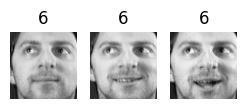

Cluster 33


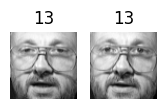

Cluster 34


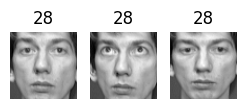

Cluster 35


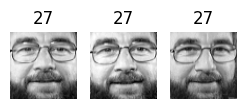

Cluster 36


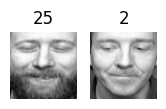

Cluster 37


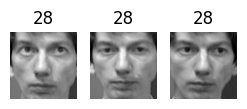

Cluster 38


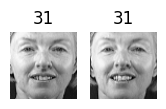

Cluster 39


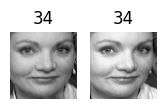

Cluster 40


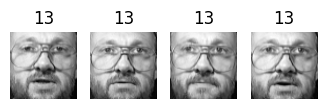

Cluster 41


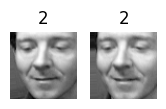

Cluster 42


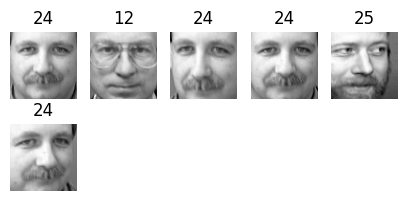

Cluster 43


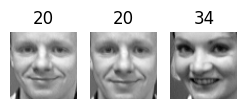

Cluster 44


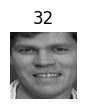

Cluster 45


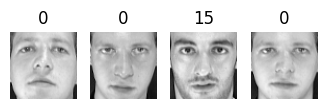

Cluster 46


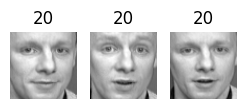

Cluster 47


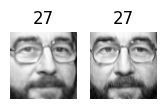

Cluster 48


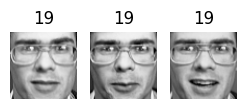

Cluster 49


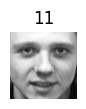

Cluster 50


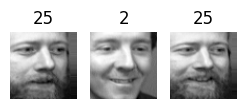

Cluster 51


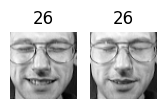

Cluster 52


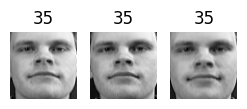

Cluster 53


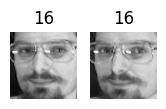

Cluster 54


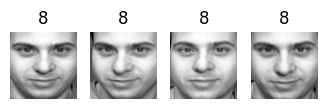

Cluster 55


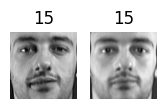

Cluster 56


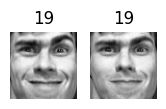

Cluster 57


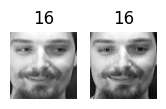

Cluster 58


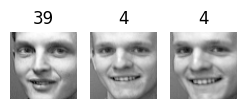

Cluster 59


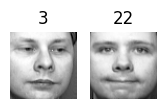

Cluster 60


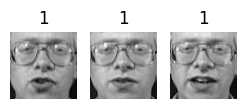

Cluster 61


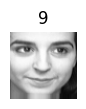

Cluster 62


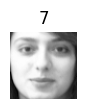

Cluster 63


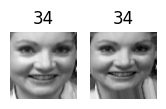

Cluster 64


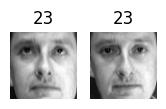

Cluster 65


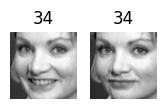

Cluster 66


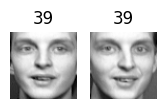

Cluster 67


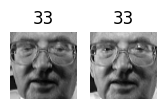

Cluster 68


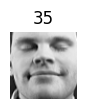

Cluster 69


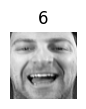

Cluster 70


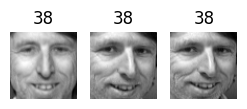

Cluster 71


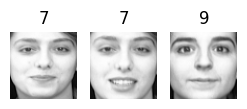

Cluster 72


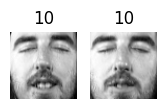

Cluster 73


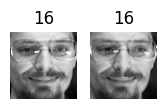

Cluster 74


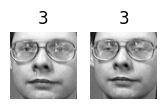

Cluster 75


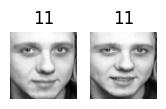

Cluster 76


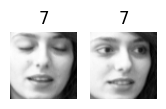

Cluster 77


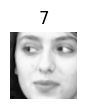

Cluster 78


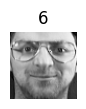

Cluster 79


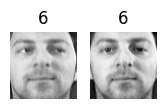

Cluster 80


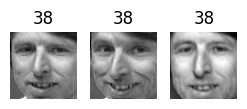

Cluster 81


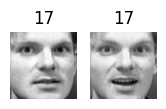

Cluster 82


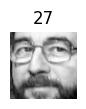

Cluster 83


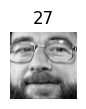

Cluster 84


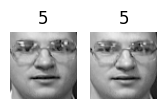

Cluster 85


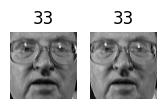

Cluster 86


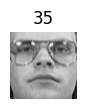

Cluster 87


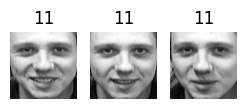

Cluster 88


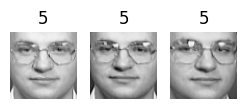

Cluster 89


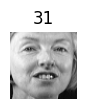

Cluster 90


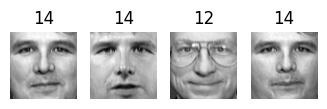

Cluster 91


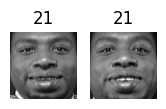

Cluster 92


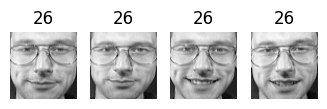

Cluster 93


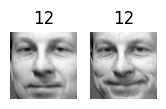

Cluster 94


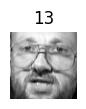

Cluster 95


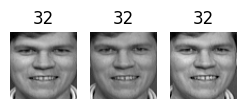

Cluster 96


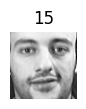

Cluster 97


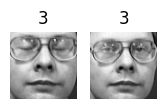

Cluster 98


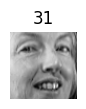

Cluster 99


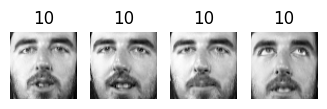

Cluster 100


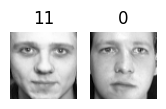

Cluster 101


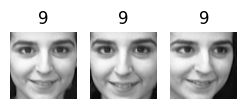

Cluster 102


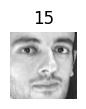

Cluster 103


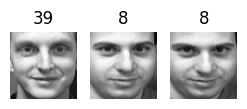

Cluster 104


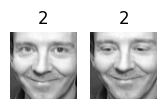

Cluster 105


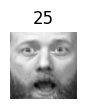

Cluster 106


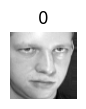

Cluster 107


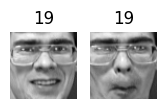

Cluster 108


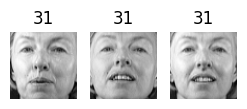

Cluster 109


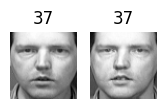

Cluster 110


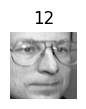

Cluster 111


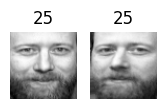

Cluster 112


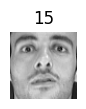

Cluster 113


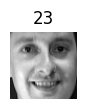

Cluster 114


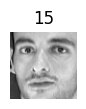

In [89]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

for cluster_id in np.unique(best_model.labels_):
    print("Cluster", cluster_id)
    in_cluster = best_model.labels_== cluster_id
    faces = X_train[in_cluster]
    labels = y_train[in_cluster]
    plot_faces(faces, labels)

In [90]:
# Problem 11 train a classifier to predict which person is in each picture

In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [92]:
params = {"max_depth": np.arange(3,50), "min_samples_split": np.arange(2,20,1), "max_leaf_nodes": np.arange(2,50), "n_estimators": np.arange(50, 200, 10)}
tree = RandomForestClassifier(random_state=42)
tree_cv = RandomizedSearchCV(tree, params, cv=3)

In [93]:
tree_cv.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': array([ 3, 4..., 47, 48, 49]), 'max_leaf_nodes': array([ 2, 3..., 47, 48, 49]), 'min_samples_split': array([ 2, 3...8, 19]), 'n_estimators': array([ 50, ... 180, 190])}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [94]:
tree_cv.score(X_val, y_val)

C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


0.9166666666666666

In [95]:
# Use Kmeans as a feature
n_ranges = np.arange(5,100,5)
k_ranges = []
for i in n_ranges:
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42) 
    kmeans.fit(X_train)
    k_ranges.append(kmeans)
# Find the best model using silhouette score
silhouette_scores = [silhouette_score(X_train, model.labels_) for model in k_ranges]
best_index = np.argmax(silhouette_scores)

best_model = k_ranges[best_index]

X_train_kmeans = best_model.transform(X_train)

In [96]:
X_train_kmeans

array([[15.737011 ,  9.333624 , 11.252818 , ..., 15.085131 , 11.054775 ,
        10.272935 ],
       [12.758494 , 11.643595 , 11.495617 , ..., 12.009069 , 10.6837   ,
        10.419728 ],
       [13.0544405,  7.599887 ,  8.642584 , ..., 11.193926 ,  6.9384313,
         7.2339964],
       ...,
       [15.394703 , 10.561955 , 10.640887 , ..., 14.0825   , 12.274341 ,
         9.925105 ],
       [ 9.818025 , 11.755622 , 11.232239 , ...,  8.689183 , 11.338826 ,
        11.014436 ],
       [12.033697 , 12.724268 , 12.352862 , ..., 11.718326 , 12.240609 ,
        11.779013 ]], shape=(280, 95), dtype=float32)

In [97]:
reduced_tree_cv = RandomizedSearchCV(tree, params, cv=3)
reduced_tree_cv.fit(X_train_kmeans, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': array([ 3, 4..., 47, 48, 49]), 'max_leaf_nodes': array([ 2, 3..., 47, 48, 49]), 'min_samples_split': array([ 2, 3...8, 19]), 'n_estimators': array([ 50, ... 180, 190])}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [98]:
X_val_kmeans = best_model.transform(X_val)

In [99]:
reduced_tree_cv.score(X_val_kmeans, y_val)

C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


0.7833333333333333

In [100]:
from sklearn.pipeline import make_pipeline

for n_clusters in n_ranges:
    pipeline = make_pipeline(
        KMeans(n_clusters=n_clusters, n_init=10, random_state=42),
        RandomizedSearchCV(tree, params,cv=3)
    )
    pipeline.fit(X_train_kmeans, y_train)
    print(n_clusters, pipeline.score(X_val_kmeans, y_val))

C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


5 0.36666666666666664


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


10 0.43333333333333335


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


15 0.43333333333333335


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


20 0.48333333333333334


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


25 0.5333333333333333


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


30 0.5166666666666667


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


35 0.5166666666666667


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


40 0.5333333333333333


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


45 0.5166666666666667


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


50 0.5


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


55 0.43333333333333335


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


60 0.5833333333333334


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


65 0.5666666666666667


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


70 0.5


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


75 0.5666666666666667


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


80 0.4166666666666667


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


85 0.6166666666666667


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


90 0.6166666666666667
95 0.5666666666666667


C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


In [101]:
X_test_kmeans = best_model.transform(X_test)

In [102]:
X_train_extended = np.c_[X_train, X_train_kmeans]
X_val_extended = np.c_[X_val, X_val_kmeans]
X_test_extended = np.c_[X_test, X_test_kmeans]

In [103]:
tree_cv = RandomizedSearchCV(tree, params, cv=3)
tree_cv.fit(X_train_extended, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': array([ 3, 4..., 47, 48, 49]), 'max_leaf_nodes': array([ 2, 3..., 47, 48, 49]), 'min_samples_split': array([ 2, 3...8, 19]), 'n_estimators': array([ 50, ... 180, 190])}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [104]:
tree_cv.score(X_val_extended, y_val)

C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


0.8833333333333333

In [105]:
cls = RandomForestClassifier(n_estimators=150, random_state=42)
cls.fit(X_train_extended, y_train)
cls.score(X_val_extended, y_val)

C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


0.95

In [106]:
# Problem 12 - Train Guassian Mixture Model
pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

In [110]:
cluster_range = np.arange(1,10)
bics = []
aics = []
mixtures = []
for k in cluster_range:
    gm = GaussianMixture(n_components = k, n_init=10)
    gm.fit(X_train_pca)

    bic = gm.bic(X_train_pca)
    aic = gm.aic(X_train_pca)

    bics.append(bic)
    aics.append(aic) 
    mixtures.append(gm)

best_index = np.argmin(bics)
best_bic = bics[best_index] 
best_aic = aics[best_index]
best_gm = mixtures[best_index]

In [111]:
print(f'Lowest BIC: {best_bic}')

Lowest BIC: 30439.64391221362


In [112]:
best_gm

,n_components,np.int64(3)
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,10
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


C:\Users\Logan\AppData\Local\Temp\ipykernel_39000\1459601563.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Information Criterion')

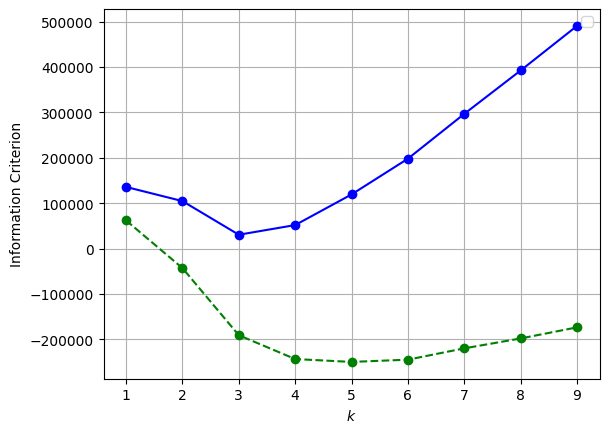

In [113]:
plt.plot(cluster_range, bics, 'bo-')
plt.plot(cluster_range, aics, 'go--')
plt.grid()
plt.legend()
plt.xlabel("$k$")
plt.ylabel("Information Criterion")

In [114]:
n_gen_faces = 20
gen_faces_reduced, y_gen_faces = gm.sample(n_samples=n_gen_faces)
gen_faces = pca.inverse_transform(gen_faces_reduced)

C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\sklearn\mixture\_base.py:443: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


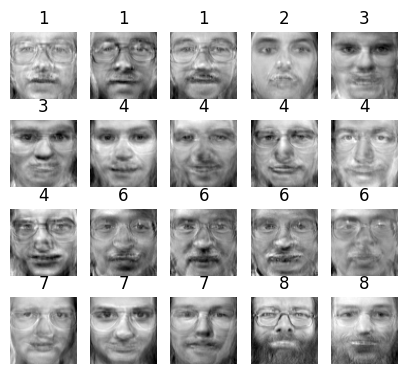

In [115]:
plot_faces(gen_faces, y_gen_faces)

In [118]:
num_rotated = 4
num_flipped = 3
num_darkened = 3

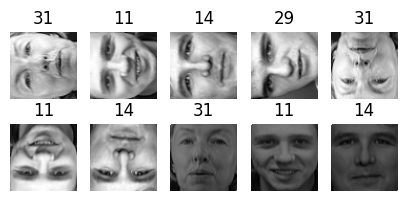

In [119]:
rotated = np.transpose(X_train[:num_rotated].reshape(-1,64,64), axes=[0,2,1])
rotated = rotated.reshape(-1, 64 * 64) 
y_rotated = y_train[:num_rotated]

flipped = X_train[:num_flipped].reshape(-1,64,64)[:,::-1] 
flipped = flipped.reshape(-1,64*64)
y_flipped = y_train[:num_flipped] 

darkened = X_train[:num_darkened].copy()
darkened[:,1:-1] *= 0.3
y_darkened = y_train[:num_darkened]

n_rotated = 4
rotated = np.transpose(X_train[:n_rotated].reshape(-1, 64, 64), axes=[0, 2, 1])
rotated = rotated.reshape(-1, 64*64)
y_rotated = y_train[:n_rotated]

n_flipped = 3
flipped = X_train[:n_flipped].reshape(-1, 64, 64)[:, ::-1]
flipped = flipped.reshape(-1, 64*64)
y_flipped = y_train[:n_flipped]

n_darkened = 3
darkened = X_train[:n_darkened].copy()
darkened[:, 1:-1] *= 0.3
y_darkened = y_train[:n_darkened]

X_bad_faces = np.r_[rotated, flipped, darkened]
y_bad = np.concatenate([y_rotated, y_flipped, y_darkened])

plot_faces(X_bad_faces, y_bad)

In [122]:
gm.score_samples(X_train_pca[:4])

array([1007.06323, 1051.1578 ,  886.53394,  985.87915], dtype=float32)

In [124]:
gm.score_samples(pca.transform(X_bad_faces))

array([-2.6708862e+07, -2.9607826e+07, -2.0525870e+07, -2.0399124e+07,
       -2.6502230e+07, -2.4352196e+07, -1.5353075e+07, -3.4210132e+07,
       -3.7893624e+07, -3.5972752e+07], dtype=float32)

In [132]:
X_train_pca.round(2)

array([[ 2.99,  2.94, -2.37, ..., -0.05,  0.11,  0.11],
       [-2.1 , -1.79,  4.28, ...,  0.13,  0.07,  0.28],
       [ 1.27, -0.72, -1.46, ..., -0.02,  0.07, -0.12],
       ...,
       [ 2.3 ,  3.96, -2.01, ..., -0.01, -0.13,  0.12],
       [-4.01, -3.03, -0.4 , ...,  0.  ,  0.06,  0.21],
       [-4.  , -1.86,  6.23, ..., -0.01, -0.21, -0.14]],
      shape=(280, 200), dtype=float32)

In [134]:
def reconstruct_errors(pca, X):
    X_pca = pca.transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)
    mse = np.square(X_reconstructed - X).mean(axis=-1)
    return mse

In [135]:
reconstruct_errors(pca, X_train).mean()

np.float32(0.00019059639)

In [136]:
reconstruct_errors(pca, X_bad_faces).mean()

np.float32(0.0054376936)

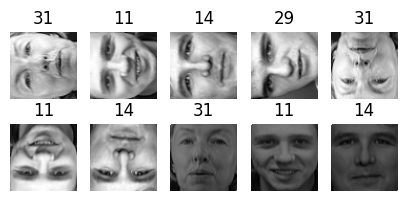

In [137]:
plot_faces(X_bad_faces, y_bad)

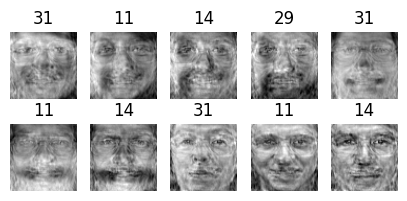

In [140]:
X_bad_faces_pca = pca.transform(X_bad_faces)
bad_faces_reconstructed = pca.inverse_transform(X_bad_faces_pca)
plot_faces(bad_faces_reconstructed, y_bad)